In [3]:
import pandas as pd
import sqlite3

cpi = pd.read_csv("../data/historicalcpi.csv")
ppi = pd.read_csv("../data/historicalppi.csv")

print(cpi.shape)
print(ppi.shape)

(1144, 3)
(832, 3)


In [4]:
conn = sqlite3.connect("../data/food_prices.db")

cpi.to_sql("cpi", conn, if_exists="replace", index=False)
ppi.to_sql("ppi", conn, if_exists="replace", index=False)

print("Tables created successfully")

Tables created successfully


In [5]:
query = """
SELECT *
FROM cpi
LIMIT 5;
"""

pd.read_sql(query, conn)

,Consumer Price Index item,Year,Percent change
0,All food,1974,14.3
1,All food,1975,8.5
2,All food,1976,3.0
3,All food,1977,6.3
4,All food,1978,9.9


In [6]:
query = """
SELECT
    [Consumer Price Index item] AS category,
    ROUND(AVG([Percent change]), 2) AS avg_inflation
FROM cpi
GROUP BY [Consumer Price Index item]
ORDER BY avg_inflation DESC
LIMIT 15;
"""

pd.read_sql(query, conn)

,category,avg_inflation
0,Sugar and sweets,4.60
1,Fresh fruits,4.51
2,Food away from home,4.27
3,Cereals and bakery products,4.26
4,Nonalcoholic beverages,4.23
5,Beef and veal,4.22
6,Fish and seafood,4.21
7,Fresh fruits and vegetables,4.19
8,Fruits and vegetables,4.00
9,Fresh vegetables,3.99


In [7]:
query = """
SELECT *
FROM cpi
WHERE [Consumer Price Index item] = 'Eggs'
ORDER BY Year;
"""

pd.read_sql(query, conn)

,Consumer Price Index item,Year,Percent change
0,Eggs,1974,0.4
1,Eggs,1975,-1.8
2,Eggs,1976,9.2
3,Eggs,1977,-3.2
4,Eggs,1978,-5.4
5,Eggs,1979,9.5
6,Eggs,1980,-1.8
7,Eggs,1981,8.2
8,Eggs,1982,-2.7
9,Eggs,1983,4.7


In [8]:
query = """
SELECT
    [Consumer Price Index item],
    Year,
    [Percent change]
FROM cpi
WHERE [Percent change] > 15
ORDER BY [Percent change] DESC;
"""

pd.read_sql(query, conn)

,Consumer Price Index item,Year,Percent change
0,Sugar and sweets,1974,52.4
1,Nonalcoholic beverages,1977,50.6
2,Fats and oils,1974,41.9
3,Eggs,2022,32.2
4,Cereals and bakery products,1974,29.9
5,Eggs,2007,29.2
6,Beef and veal,1979,27.4
7,Eggs,1989,26.6
8,Sugar and sweets,1975,26.1
9,Sugar and sweets,1980,23.0


In [9]:
query = """
SELECT
    [Consumer Price Index item] AS category,
    ROUND(AVG([Percent change]),2) AS avg_inflation
FROM cpi
GROUP BY [Consumer Price Index item]
HAVING AVG([Percent change]) > 4
ORDER BY avg_inflation DESC;
"""

pd.read_sql(query, conn)

,category,avg_inflation
0,Sugar and sweets,4.60
1,Fresh fruits,4.51
2,Food away from home,4.27
3,Cereals and bakery products,4.26
4,Nonalcoholic beverages,4.23
5,Beef and veal,4.22
6,Fish and seafood,4.21
7,Fresh fruits and vegetables,4.19
8,Fruits and vegetables,4.00


In [10]:
query = """
SELECT
    COUNT(DISTINCT [Consumer Price Index item]) AS total_categories,
    ROUND(AVG([Percent change]),2) AS avg_inflation,
    ROUND(MAX([Percent change]),2) AS max_inflation,
    ROUND(MIN([Percent change]),2) AS min_inflation
FROM cpi;
"""

pd.read_sql(query, conn)

,total_categories,avg_inflation,max_inflation,min_inflation
0,22,3.82,52.4,-21.1


In [11]:
cpi_join = cpi.rename(columns={
    "Year":"year",
    "Percent change":"cpi_change"
})

ppi_join = ppi.rename(columns={
    "Year":"year",
    "Percent change":"ppi_change"
})

In [12]:
cpi_join.to_sql("cpi_join", conn,
                if_exists="replace",
                index=False)

ppi_join.to_sql("ppi_join", conn,
                if_exists="replace",
                index=False)

832

In [13]:
query = """
SELECT
    c.year,
    ROUND(AVG(c.cpi_change),2) AS avg_cpi,
    ROUND(AVG(p.ppi_change),2) AS avg_ppi
FROM cpi_join c
INNER JOIN ppi_join p
ON c.year = p.year
GROUP BY c.year
ORDER BY c.year;
"""

pd.read_sql(query, conn)

,year,avg_cpi,avg_ppi
0,1974,13.61,11.47
1,1975,8.56,0.77
2,1976,2.32,-3.31
3,1977,6.77,0.82
4,1978,11.22,12.78
5,1979,10.29,11.82
6,1980,7.38,3.56
7,1981,7.87,3.30
8,1982,3.43,-2.75
9,1983,1.04,2.09


In [14]:
cpi_ppi = pd.read_sql(query, conn)

cpi_ppi.head()

,year,avg_cpi,avg_ppi
0,1974,13.61,11.47
1,1975,8.56,0.77
2,1976,2.32,-3.31
3,1977,6.77,0.82
4,1978,11.22,12.78


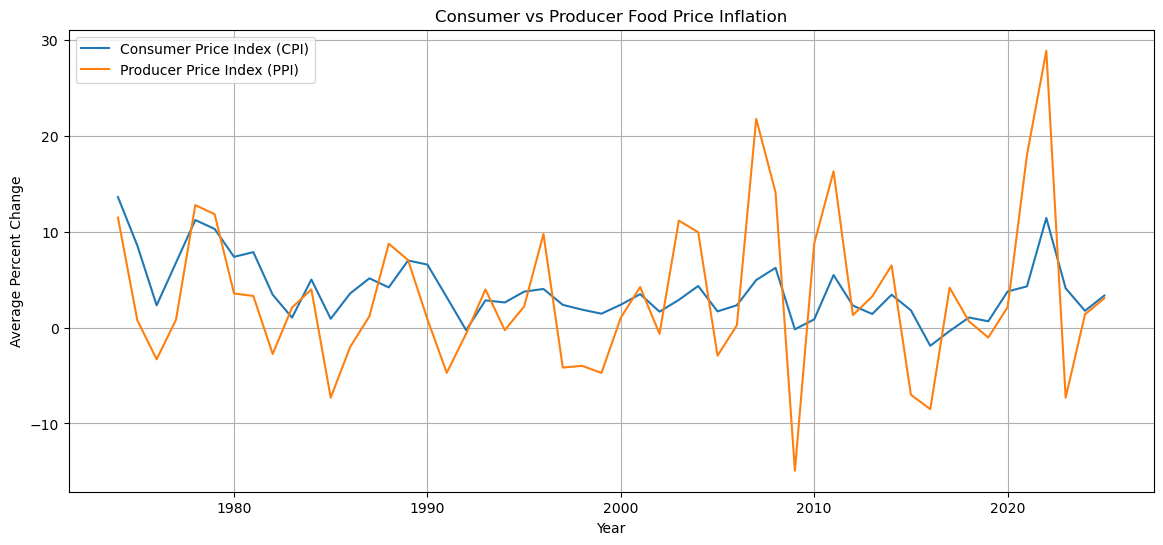

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    cpi_ppi["year"],
    cpi_ppi["avg_cpi"],
    label="Consumer Price Index (CPI)"
)

plt.plot(
    cpi_ppi["year"],
    cpi_ppi["avg_ppi"],
    label="Producer Price Index (PPI)"
)

plt.title("Consumer vs Producer Food Price Inflation")
plt.xlabel("Year")
plt.ylabel("Average Percent Change")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
cpi_ppi[["avg_cpi","avg_ppi"]].corr()

,avg_cpi,avg_ppi
avg_cpi,1.000000,0.594723
avg_ppi,0.594723,1.000000


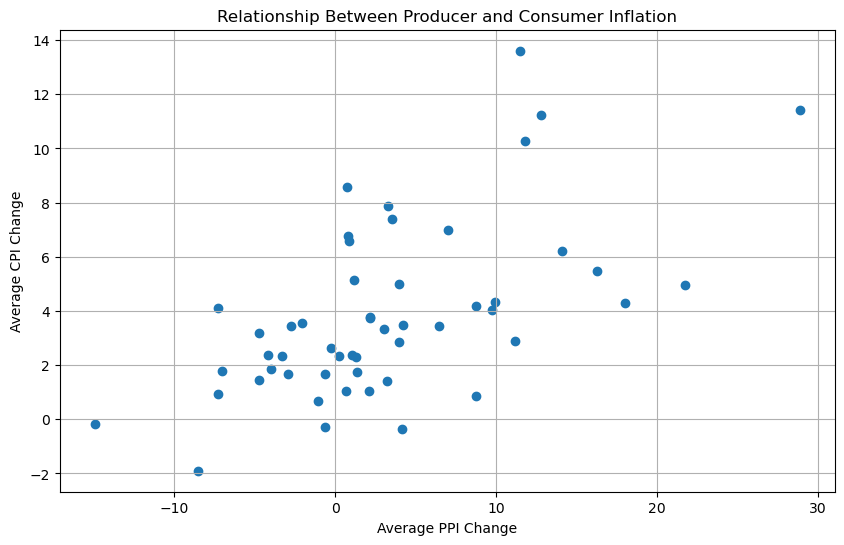

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    cpi_ppi["avg_ppi"],
    cpi_ppi["avg_cpi"]
)

plt.xlabel("Average PPI Change")
plt.ylabel("Average CPI Change")
plt.title("Relationship Between Producer and Consumer Inflation")

plt.grid(True)

plt.show()

In [20]:
avg_cpi = (
    cpi.groupby("Consumer Price Index item")["Percent change"]
       .mean()
       .reset_index()
       .sort_values("Percent change", ascending=False)
)

In [21]:
avg_cpi.to_csv("../dashboard/avg_cpi.csv", index=False)
cpi.to_csv("../dashboard/cpi.csv", index=False)
ppi.to_csv("../dashboard/ppi.csv", index=False)
cpi_ppi.to_csv("../dashboard/cpi_ppi.csv", index=False)

print("SQL and KPI files exported successfully")

SQL and KPI files exported successfully
